# E5b — Anchor-distance robustness sweep (reproducer)

Top-to-bottom reproducer for `docs/experiments/E5b-anchor-distance-design.md`.
Reads the latest VQAv2 + TallyQA stratified runs under `outputs/experiment_distance_*/llava-next-interleaved-7b/<timestamp>/predictions.jsonl` and regenerates:

1. Per-stratum summary table (direction-follow / adoption / EM / mean distance, with 95% bootstrap CI).
2. Distance curve per dataset.
3. Cross-dataset overlay.

All heavy lifting lives in `scripts/analyze_e5b_distance.py` — this notebook just invokes it and displays the outputs.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'scripts'))
from analyze_e5b_distance import run
out = run()
summary = out['summary']
print(f"loaded {out['n_records']} records, wrote {out['out_csv']}")

loaded 12000 records, wrote docs/insights/_data/E5b_per_stratum.csv


## Per-stratum summary

Each row = one (dataset, stratum) cell. `direction_follow_rate` is the headline number; `df_minus_baseline` subtracts the per-dataset target_only direction-follow (≈0 by construction).

In [2]:
import pandas as pd
pd.set_option('display.float_format', '{:0.3f}'.format)
summary

,dataset,stratum,stratum_range,stratum_midpoint,n,direction_follow_rate,direction_follow_ci_lo,direction_follow_ci_hi,adoption_rate,exact_match,mean_distance_to_anchor,df_minus_baseline
0,VQAv2,S1,"[0,1]",0.500,1000,0.182,0.159,0.206,0.080,0.579,0.975,0.182
1,VQAv2,S2,"[2,5]",3.500,1000,0.274,0.246,0.301,0.028,0.563,3.177,0.274
2,VQAv2,S3,"[6,30]",18.000,1000,0.193,0.166,0.219,0.016,0.565,15.303,0.193
3,VQAv2,S4,"[31,300]",165.000,1000,0.186,0.162,0.212,0.014,0.568,88.426,0.186
4,VQAv2,S5,"[301,inf)",650.000,1000,0.186,0.162,0.211,0.009,0.565,5295.330,0.186
5,TallyQA,S1,"[0,1]",0.500,1000,0.127,0.106,0.149,0.041,0.652,0.918,0.127
6,TallyQA,S2,"[2,5]",3.500,1000,0.211,0.186,0.236,0.005,0.637,3.340,0.211
7,TallyQA,S3,"[6,30]",18.000,1000,0.148,0.126,0.170,0.002,0.633,15.626,0.148
8,TallyQA,S4,"[31,300]",165.000,1000,0.153,0.131,0.176,0.000,0.627,90.778,0.153
9,TallyQA,S5,"[301,inf)",650.000,1000,0.140,0.119,0.160,0.000,0.645,5206.179,0.140


## Distance curve per dataset

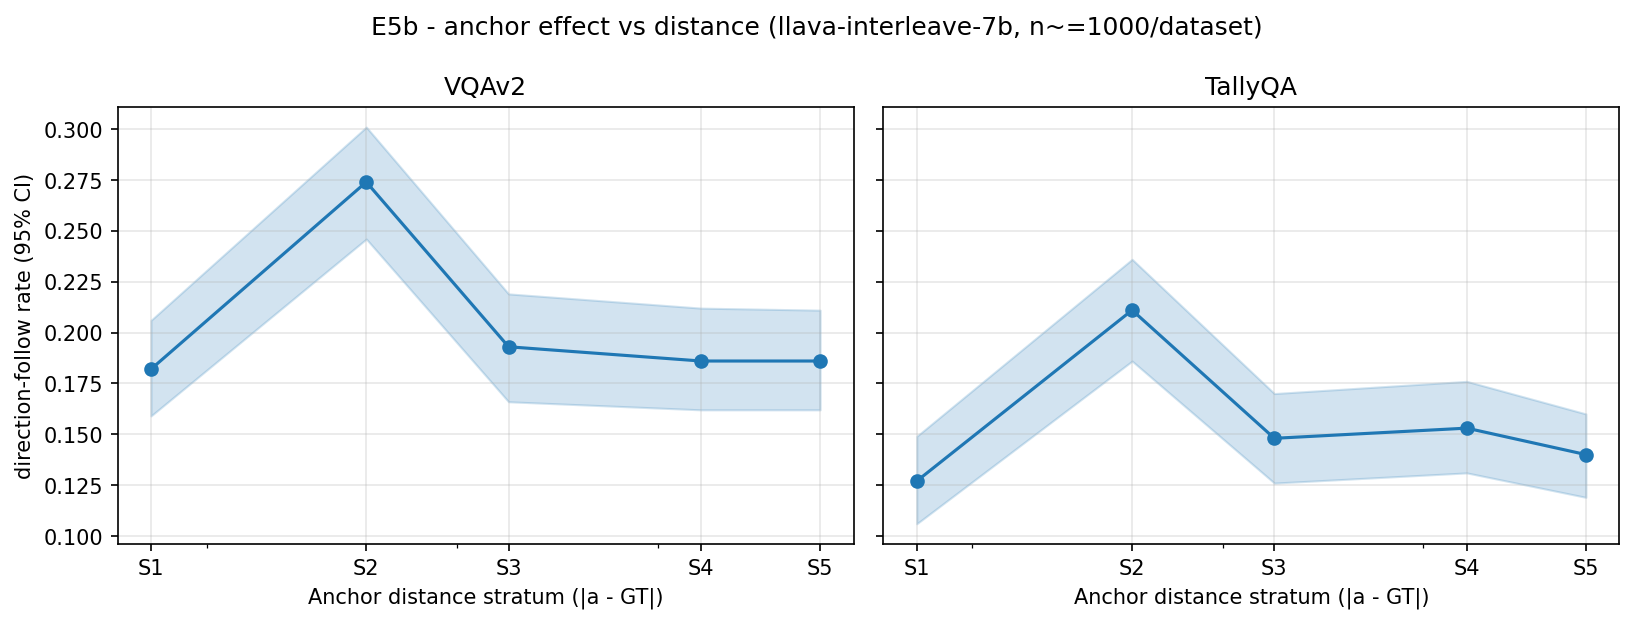

In [3]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / 'docs' / 'figures' / 'E5b_distance_curve.png')))

## Cross-dataset overlay

Two lines on one axis. The cutoff `d*` for paper-headline subset is the largest stratum where the effect remains > 50% of S1's effect.

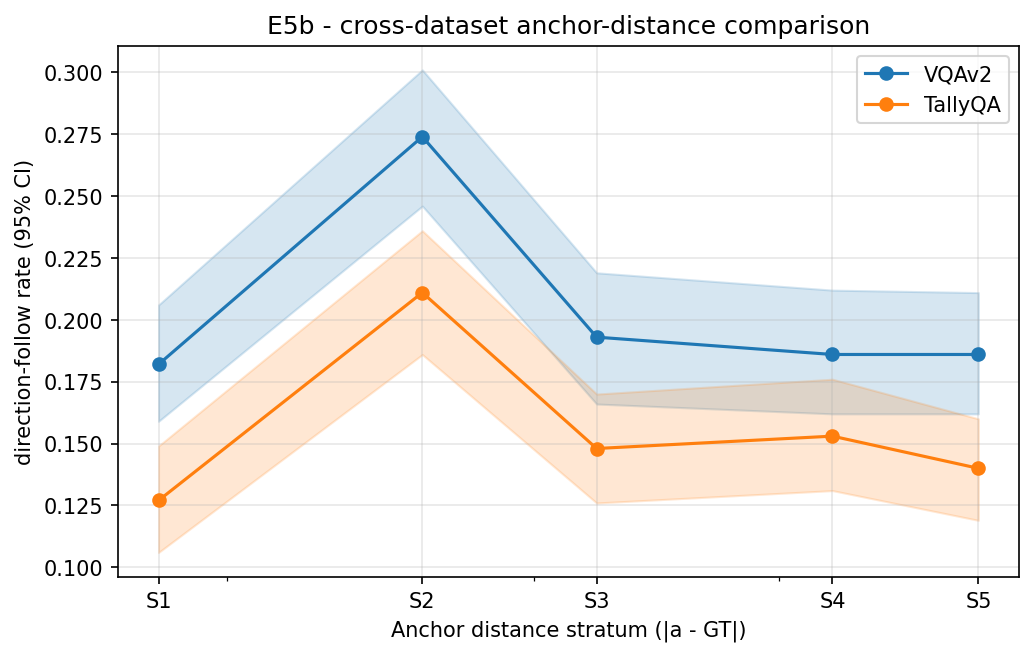

In [4]:
display(Image(filename=str(ROOT / 'docs' / 'figures' / 'E5b_cross_dataset_overlay.png')))

## Sanity check vs main run

VQAv2 main run (random anchor 0–9, n=17,730) had `direction_follow_rate = 0.348` on llava-interleave-7b. If E5b's anchor-distance distribution were uniform random over 0–9, the pooled effect would land near 0.348. The stratified sweep oversamples far strata (S4/S5), so we expect the pooled E5b direction-follow to be **lower** than 0.348.

In [5]:
vqa_pool = summary[summary['dataset'] == 'VQAv2']
n_total = vqa_pool['n'].sum()
weighted_df = float((vqa_pool['direction_follow_rate'] * vqa_pool['n']).sum() / n_total)
print(f'E5b VQAv2 pooled direction-follow (n={n_total}): {weighted_df:.3f}')
print(f'reference — main run random-anchor 0..9 (n=17,730):  0.348')

E5b VQAv2 pooled direction-follow (n=5000): 0.204
reference — main run random-anchor 0..9 (n=17,730):  0.348
